# Notebook 9: S1, S2, And S3 THOR Workflow

This notebook combines a live Sentinel-1, Sentinel-2, and Sentinel-3 quartet matcher with a THOR-ready export workflow. The goal is to:

1. search Sentinel-1, Sentinel-2, and Sentinel-3 products over one AOI and time window,
2. pick the best quartet in time,
3. show the matching decision directly in GitHub-rendered outputs, and
4. end with modality-specific GeoTIFF exports that are easier to use from terratorch or a future dict-enabled THOR model input.

The workflow deliberately separates the "discovery and explanation" part from the "download and export" part so the repository preview stays readable while the heavy steps remain runnable locally.

## Task Definition
- Inputs: AOI WKT, date window, per-sensor search limit, cloud threshold, and target GSDs for S1, S2, OLCI, SLSTR reflectance, and SLSTR brightness temperatures.
- Outputs: one selected S1/S2/S3 quartet, timing diagnostics, modality-specific GeoTIFF stacks, and JSON or CSV manifests describing the exported ROI.
- Success criteria: the notebook finds one best-time quartet, exports aligned rasters in one projected CRS with one shared origin, preserves the requested modality resolutions, and saves band metadata for downstream loading.
- Constraints and assumptions: Sentinel-3 is matched and processed from Level-1 products because the THOR Sentinel-3 workflow starts from radiance and brightness temperature files. The notebook keeps modalities separate by default and optionally creates one fused 240 m Sentinel-3 stack for direct THOR-style ingestion.
- Delivery target: provide one notebook that shows product matching in GitHub and ends in modality-specific GeoTIFF exports suitable for terratorch or a future dict-enabled THOR input path.

Read the notebook in three passes:
1. up to the repo preview boundary if you only want to understand the matching and alignment plan,
2. through the export cell if you want actual GeoTIFF outputs,
3. through the dict-style example if you want to wire the outputs into model code.

## Environment Setup

This cell lists the notebook-local dependencies instead of changing the package itself. The idea is to keep `phidown` lightweight while still documenting the full stack needed for reprojection, NetCDF reading, and swath resampling.

Practical notes:
- Launch Jupyter from the project `.venv` when possible. It avoids many GDAL, PROJ, and rasterio path conflicts.
- The import cell below explicitly points `PROJ_DATA` and `PROJ_LIB` to rasterio's bundled PROJ directory. This protects the notebook from inherited conda shell variables that can otherwise break raster IO with a `proj.db` version mismatch.
- Install `torch` only if you want to build actual tensors in the last example cell. The matching and export logic does not require it.
- For the repository preview we execute only the safe pre-download cells. The heavy cells stay runnable locally.

In [1]:
# %pip install --quiet phidown rasterio xarray netCDF4 h5netcdf pyresample shapely matplotlib folium ipyleaflet
# Optional if you want to materialise torch tensors in the final example cell:
# %pip install --quiet torch

## Imports

The imports are grouped by responsibility:
- `pandas`, `numpy`, and `itertools` for catalogue analysis and scoring.
- `folium` and `matplotlib` for the human-readable diagnostics.
- `rasterio`, `xarray`, `pyproj`, `pyresample`, and `shapely` for the geospatial export path.
- `CopernicusDataSearcher` for catalogue search and live product download.

If one import fails, stop here and fix the environment before trusting later outputs. Most downstream issues in this workflow come from missing geospatial dependencies rather than from the matching logic itself.

In [2]:
from __future__ import annotations

import json
import math
import os
from itertools import combinations
from pathlib import Path

import folium
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import rasterio._env
import xarray as xr
from IPython.display import display
from pyproj import CRS, Transformer
from pyresample import geometry, kd_tree

proj_data_dir = rasterio._env.PROJDataFinder().search()
rasterio._env.set_proj_data_search_path(proj_data_dir)
os.environ["PROJ_DATA"] = proj_data_dir
os.environ["PROJ_LIB"] = proj_data_dir

from rasterio.enums import Resampling
from rasterio.features import geometry_mask
from rasterio.transform import array_bounds, from_gcps, from_origin
from rasterio.warp import calculate_default_transform, reproject
from shapely import wkt as shapely_wkt
from shapely.geometry import mapping, shape
from shapely.ops import transform as shapely_transform, unary_union

from phidown.search import CopernicusDataSearcher

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass


## Parameters

This is the only cell you usually need to edit first.

What each parameter group controls:
- `aoi_wkt`, `start_date`, `end_date`: the search domain.
- `top_per_sensor`, `cloud_cover_threshold`: catalogue filtering.
- `download_dir`, `output_dir`: where raw products and exported ROI files go.
- `*_target_resolution_m`: the aligned export grid per modality.
- `export_s3_combined_240m`: whether to additionally create one fused Sentinel-3 stack.
- `swath_radius_of_influence_m` and `swath_pad_degrees`: how aggressively the swath products are cropped and resampled.

Recommended first run:
1. keep the default small AOI and narrow date range,
2. leave `export_s3_combined_240m = False`,
3. run only through the repo preview boundary,
4. enable downloads only once the chosen quartet looks reasonable.

In [3]:
aoi_wkt = "POLYGON ((12.350000 41.800000, 12.350000 42.020000, 12.650000 42.020000, 12.650000 41.800000, 12.350000 41.800000))"
start_date = "2024-04-24T00:00:00"
end_date = "2024-04-30T23:59:59"
top_per_sensor = 100
cloud_cover_threshold = 20
min_aoi_overlap = 0.2  # Minimum fraction of AOI covered by a product footprint.

download_dir = "./data/9_s1_s2_s3_thor_workflow"
output_dir = "./out/9_s1_s2_s3_thor_workflow"

s1_target_resolution_m = 10
s2_target_resolution_m = 10
olci_target_resolution_m = 240
slstr_reflectance_resolution_m = 480
slstr_bt_resolution_m = 960
export_s3_combined_240m = False  # Keep OLCI and SLSTR separate GeoTIFFs by default.
s3_combined_resolution_m = 240
swath_radius_of_influence_m = 1500.0
swath_pad_degrees = 0.25

s2_band_order = [
    "B01",
    "B02",
    "B03",
    "B04",
    "B05",
    "B06",
    "B07",
    "B08",
    "B8A",
    "B09",
    "B11",
    "B12",
]

resolution_map = {
    "S1GRD": int(s1_target_resolution_m),
    "S2L2A": int(s2_target_resolution_m),
    "S3OLCI": int(olci_target_resolution_m),
    "S3SLSTR_REFL": int(slstr_reflectance_resolution_m),
    "S3SLSTR_BT": int(slstr_bt_resolution_m),
}
if export_s3_combined_240m:
    resolution_map["S3COMBINED"] = int(s3_combined_resolution_m)

download_path = Path(download_dir).expanduser().resolve()
output_path = Path(output_dir).expanduser().resolve()
download_path.mkdir(parents=True, exist_ok=True)
output_path.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 120)
print("Download path:", download_path)
print("Output path:", output_path)
display(pd.DataFrame({"modality": list(resolution_map), "target_resolution_m": list(resolution_map.values())}))

Download path: /home/theodor/Projects/phidown/notebooks/data/9_s1_s2_s3_thor_workflow
Output path: /home/theodor/Projects/phidown/notebooks/out/9_s1_s2_s3_thor_workflow


,modality,target_resolution_m
0,S1GRD,10
1,S2L2A,10
2,S3OLCI,240
3,S3SLSTR_REFL,480
4,S3SLSTR_BT,960


## Search And Matching Helpers

This section defines the catalogue logic.

What happens here:
- We define one search configuration per sensor family.
- We normalise catalogue timestamps into UTC `pandas.Timestamp` objects.
- We use Sentinel-1 as the anchor sensor to keep the selection deterministic and consistent with the earlier S1-led matching examples in this repository.
- For each Sentinel-1 acquisition we pick the nearest S2, OLCI, and SLSTR acquisition in time.
- We score each quartet with a lexicographic rule:
  1. minimise the total span between earliest and latest start time,
  2. break ties with the sum of all pairwise time deltas.

This is a temporal matcher, not a strict footprint-intersection solver. Spatial consistency comes from searching all sensors over the same AOI and then inspecting the footprint map before downloading.

In [4]:
SENSOR_CONFIG = {
    "s1_grd": {
        "label": "Sentinel-1 GRD",
        "collection_name": "SENTINEL-1",
        "product_type": "GRD",
        "color": "#1f77b4",
    },
    "s2_l2a": {
        "label": "Sentinel-2 L2A",
        "collection_name": "SENTINEL-2",
        "product_type": "S2MSI2A",
        "color": "#2ca02c",
    },
    "s3_olci_l1": {
        "label": "Sentinel-3 OLCI EFR L1",
        "collection_name": "SENTINEL-3",
        "attributes": {
            "instrumentShortName": "OLCI",
            "processingLevel": "1",
            "productType": "OL_1_EFR___",
        },
        "color": "#ff7f0e",
    },
    "s3_slstr_l1": {
        "label": "Sentinel-3 SLSTR RBT L1",
        "collection_name": "SENTINEL-3",
        "attributes": {
            "instrumentShortName": "SLSTR",
            "processingLevel": "1",
            "productType": "SL_1_RBT___",
        },
        "color": "#d62728",
    },
}

SENSOR_ORDER = list(SENSOR_CONFIG)


def _content_time(item: dict, key: str) -> pd.Timestamp:
    return pd.to_datetime(item[key], utc=True)


def _parse_footprint(geo_footprint) -> object:
    """Parse a GeoFootprint field into a shapely geometry."""
    if isinstance(geo_footprint, dict):
        return shape(geo_footprint)
    return shape(json.loads(geo_footprint))


def compute_aoi_overlap(df: pd.DataFrame, aoi_wkt: str) -> pd.DataFrame:
    """Add an 'aoi_overlap' column: fraction of the AOI covered by each product."""
    aoi_geom = shapely_wkt.loads(aoi_wkt)
    aoi_area = aoi_geom.area
    overlaps = []
    for footprint in df["GeoFootprint"]:
        product_geom = _parse_footprint(footprint)
        intersection = aoi_geom.intersection(product_geom)
        overlaps.append(intersection.area / aoi_area if aoi_area > 0 else 0.0)
    result = df.copy()
    result["aoi_overlap"] = overlaps
    return result


def filter_by_aoi_overlap(
    df: pd.DataFrame, aoi_wkt: str, min_overlap: float
) -> pd.DataFrame:
    """Keep only products covering at least min_overlap fraction of the AOI."""
    df = compute_aoi_overlap(df, aoi_wkt)
    return df[df["aoi_overlap"] >= min_overlap].reset_index(drop=True)


def prepare_results(df: pd.DataFrame, sensor_key: str) -> pd.DataFrame:
    prepared = df.copy()
    prepared["sensor_key"] = sensor_key
    prepared["sensor_label"] = SENSOR_CONFIG[sensor_key]["label"]
    prepared["start_time"] = prepared["ContentDate"].apply(lambda item: _content_time(item, "Start"))
    prepared["end_time"] = prepared["ContentDate"].apply(lambda item: _content_time(item, "End"))
    prepared = prepared.sort_values("start_time").reset_index(drop=True)
    return prepared


def query_sensor(
    sensor_key: str,
    *,
    aoi_wkt: str,
    start_date: str,
    end_date: str,
    top_per_sensor: int,
    cloud_cover_threshold: float,
) -> pd.DataFrame:
    cfg = SENSOR_CONFIG[sensor_key]
    kwargs = {
        "collection_name": cfg["collection_name"],
        "aoi_wkt": aoi_wkt,
        "start_date": start_date,
        "end_date": end_date,
        "top": top_per_sensor,
        "count": False,
    }
    if "product_type" in cfg:
        kwargs["product_type"] = cfg["product_type"]
    if sensor_key == "s2_l2a":
        kwargs["cloud_cover_threshold"] = cloud_cover_threshold
    if "attributes" in cfg:
        kwargs["attributes"] = dict(cfg["attributes"])

    searcher = CopernicusDataSearcher()
    searcher.query_by_filter(**kwargs)
    df = searcher.execute_query().copy()
    if df.empty:
        raise LookupError(f"No results found for {cfg['label']}")
    return prepare_results(df, sensor_key)


def nearest_match_row(df: pd.DataFrame, target_time: pd.Timestamp) -> pd.Series:
    offsets = (df["start_time"] - target_time).abs()
    idx = offsets.idxmin()
    return df.loc[idx]


def quartet_for_anchor(anchor_row: pd.Series, tables: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = [anchor_row]
    for sensor_key in SENSOR_ORDER[1:]:
        rows.append(nearest_match_row(tables[sensor_key], anchor_row["start_time"]))
    quartet_df = pd.DataFrame(rows).copy()
    quartet_df["sensor_key"] = pd.Categorical(quartet_df["sensor_key"], SENSOR_ORDER, ordered=True)
    quartet_df = quartet_df.sort_values("sensor_key").reset_index(drop=True)
    quartet_df["sensor_key"] = quartet_df["sensor_key"].astype(str)
    quartet_df["sensor_label"] = quartet_df["sensor_key"].map(lambda key: SENSOR_CONFIG[key]["label"])
    return quartet_df


def compute_median_time(starts: pd.Series) -> pd.Timestamp:
    median_ns = int(np.median(starts.astype("int64")))
    # Round to microseconds so later plotting does not emit nanosecond warnings.
    return pd.to_datetime(median_ns, utc=True).round("us")


def compute_quartet_metrics(quartet_df: pd.DataFrame) -> dict:
    starts = quartet_df["start_time"].sort_values().reset_index(drop=True)
    span = starts.iloc[-1] - starts.iloc[0]
    pairwise_seconds = sum(
        abs((left - right).total_seconds())
        for left, right in combinations(quartet_df["start_time"], 2)
    )
    median_time = compute_median_time(quartet_df["start_time"])
    anchor_time = quartet_df.loc[quartet_df["sensor_key"] == "s1_grd", "start_time"].iloc[0]
    return {
        "span": span,
        "span_hours": span.total_seconds() / 3600.0,
        "pairwise_seconds": pairwise_seconds,
        "pairwise_hours": pairwise_seconds / 3600.0,
        "median_time": median_time,
        "anchor_time": anchor_time,
    }


def build_quartet_summary(quartet_df: pd.DataFrame, metrics: dict) -> pd.DataFrame:
    summary = quartet_df.copy()
    summary["delta_from_median_h"] = (
        (summary["start_time"] - metrics["median_time"]).dt.total_seconds() / 3600.0
    )
    summary["delta_from_anchor_h"] = (
        (summary["start_time"] - metrics["anchor_time"]).dt.total_seconds() / 3600.0
    )
    return summary[
        [
            "sensor_key",
            "sensor_label",
            "Name",
            "start_time",
            "end_time",
            "delta_from_median_h",
            "delta_from_anchor_h",
        ]
    ].copy()


def find_best_quartet(tables: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, dict, pd.DataFrame]:
    best = None
    for _, anchor_row in tables["s1_grd"].iterrows():
        quartet_df = quartet_for_anchor(anchor_row, tables)
        metrics = compute_quartet_metrics(quartet_df)
        key = (metrics["span"].total_seconds(), metrics["pairwise_seconds"])
        if best is None or key < best["key"]:
            best = {
                "key": key,
                "quartet_df": quartet_df,
                "metrics": metrics,
            }

    if best is None:
        raise LookupError("Unable to build a four-sensor quartet from the search results")

    summary = build_quartet_summary(best["quartet_df"], best["metrics"])
    return best["quartet_df"], best["metrics"], summary


def print_quartet_report(summary: pd.DataFrame, metrics: dict) -> None:
    print("Selected quartet:")
    for row in summary.itertuples(index=False):
        print(f"- {row.sensor_label}: {row.Name}")
        print(
            "  "
            + f"start={row.start_time} end={row.end_time} "
            + f"delta_from_median_h={row.delta_from_median_h:.2f} "
            + f"delta_from_anchor_h={row.delta_from_anchor_h:.2f}"
        )
    print(f"Total quartet span: {metrics['span_hours']:.2f} hours")
    print(f"Sum of pairwise deltas: {metrics['pairwise_hours']:.2f} hours")
    print(f"Median sensing time: {metrics['median_time']}")

## Execute The Four Searches

This cell runs the live catalogue queries and shows two kinds of output:
- one compact overview table with result counts and time coverage per sensor,
- a few sample rows per sensor so you can immediately verify that the returned products look sensible.

Before trusting the rest of the notebook, check these outputs for:
- empty result tables,
- clearly wrong product families,
- suspicious sensing times,
- Sentinel-3 products that do not match the intended Level-1 types.

In [5]:
search_tables = {}
search_overview = []
for sensor_key in SENSOR_ORDER:
    table = query_sensor(
        sensor_key,
        aoi_wkt=aoi_wkt,
        start_date=start_date,
        end_date=end_date,
        top_per_sensor=top_per_sensor,
        cloud_cover_threshold=cloud_cover_threshold,
    )
    raw_count = len(table)
    table = filter_by_aoi_overlap(table, aoi_wkt, min_aoi_overlap)
    search_tables[sensor_key] = table
    search_overview.append(
        {
            "sensor": SENSOR_CONFIG[sensor_key]["label"],
            "raw_rows": raw_count,
            "rows_after_overlap_filter": len(table),
            "first_start": table["start_time"].min() if len(table) else None,
            "last_start": table["start_time"].max() if len(table) else None,
        }
    )
    if table.empty:
        raise LookupError(
            f"No {SENSOR_CONFIG[sensor_key]['label']} products have >= {min_aoi_overlap:.0%} AOI overlap"
        )

search_overview_df = pd.DataFrame(search_overview)
display(search_overview_df)
for sensor_key in SENSOR_ORDER:
    display(
        search_tables[sensor_key][
            ["Name", "start_time", "end_time", "aoi_overlap"]
        ].head(3)
    )

,sensor,raw_rows,rows_after_overlap_filter,first_start,last_start
0,Sentinel-1 GRD,2,2,2024-04-29 05:12:03.379975+00:00,2024-04-29 05:12:28.381049+00:00
1,Sentinel-2 L2A,2,2,2024-04-29 09:55:49.024000+00:00,2024-04-29 09:55:49.024000+00:00
2,Sentinel-3 OLCI EFR L1,11,10,2024-04-24 08:56:49.886029+00:00,2024-04-30 09:41:45.097473+00:00
3,Sentinel-3 SLSTR RBT L1,23,23,2024-04-24 08:56:49.886623+00:00,2024-04-30 21:01:39.890493+00:00


,Name,start_time,end_time,aoi_overlap
0,S1A_IW_GRDH_1SDV_20240429T051203_20240429T051228_053644_0683B5_A41F.SAFE,2024-04-29 05:12:03.379975+00:00,2024-04-29 05:12:28.379556+00:00,0.514997
1,S1A_IW_GRDH_1SDV_20240429T051228_20240429T051253_053644_0683B5_E178.SAFE,2024-04-29 05:12:28.381049+00:00,2024-04-29 05:12:53.379130+00:00,0.484645


,Name,start_time,end_time,aoi_overlap
0,S2B_MSIL2A_20240429T095549_N0510_R122_T32TQM_20240429T144150.SAFE,2024-04-29 09:55:49.024000+00:00,2024-04-29 09:55:49.024000+00:00,1.0
1,S2B_MSIL2A_20240429T095549_N0510_R122_T33TTG_20240429T144150.SAFE,2024-04-29 09:55:49.024000+00:00,2024-04-29 09:55:49.024000+00:00,1.0


,Name,start_time,end_time,aoi_overlap
0,S3B_OL_1_EFR____20240424T085650_20240424T085950_20240921T140106_0180_092_164_2160_MAR_R_NT_004.SEN3,2024-04-24 08:56:49.886029+00:00,2024-04-24 08:59:49.886029+00:00,0.844338
1,S3A_OL_1_EFR____20240424T093547_20240424T093847_20240920T131943_0179_111_307_2160_MAR_R_NT_004.SEN3,2024-04-24 09:35:46.705421+00:00,2024-04-24 09:38:46.705421+00:00,1.000000
2,S3A_OL_1_EFR____20240425T090936_20240425T091236_20240920T143057_0179_111_321_2160_MAR_R_NT_004.SEN3,2024-04-25 09:09:36.278422+00:00,2024-04-25 09:12:36.278422+00:00,1.000000


,Name,start_time,end_time,aoi_overlap
0,S3B_SL_1_RBT____20240424T085650_20240424T085950_20240424T224048_0179_092_164_2160_PS2_O_NT_004.SEN3,2024-04-24 08:56:49.886623+00:00,2024-04-24 08:59:49.886623+00:00,0.770106
1,S3B_SL_1_RBT____20240424T085950_20240424T090250_20240424T224107_0179_092_164_2340_PS2_O_NT_004.SEN3,2024-04-24 08:59:49.886623+00:00,2024-04-24 09:02:49.886623+00:00,0.204690
2,S3A_SL_1_RBT____20240424T093547_20240424T093847_20240425T191511_0179_111_307_2160_PS1_O_NT_004.SEN3,2024-04-24 09:35:46.705477+00:00,2024-04-24 09:38:46.705477+00:00,1.000000


## Choose The Best Quartet In Time

This is the decision point of the notebook.

The output answers:
- which four products were selected,
- how far each product is from the quartet median time,
- how far each non-S1 product is from the S1 anchor time,
- how large the overall quartet span is.

If this table looks bad, do not continue to downloads. Widen the date window, change the AOI, or lower the filtering strictness first.

In [6]:
selected_quartet_df, selected_metrics, quartet_summary_df = find_best_quartet(search_tables)
print_quartet_report(quartet_summary_df, selected_metrics)
display(quartet_summary_df)

Selected quartet:
- Sentinel-1 GRD: S1A_IW_GRDH_1SDV_20240429T051228_20240429T051253_053644_0683B5_E178.SAFE
  start=2024-04-29 05:12:28.381049+00:00 end=2024-04-29 05:12:53.379130+00:00 delta_from_median_h=-3.89 delta_from_anchor_h=0.00
- Sentinel-2 L2A: S2B_MSIL2A_20240429T095549_N0510_R122_T32TQM_20240429T144150.SAFE
  start=2024-04-29 09:55:49.024000+00:00 end=2024-04-29 09:55:49.024000+00:00 delta_from_median_h=0.83 delta_from_anchor_h=4.72
- Sentinel-3 OLCI EFR L1: S3A_OL_1_EFR____20240429T090553_20240429T090853_20240920T125756_0179_111_378_2160_MAR_R_NT_004.SEN3
  start=2024-04-29 09:05:53.177253+00:00 end=2024-04-29 09:08:53.177253+00:00 delta_from_median_h=0.00 delta_from_anchor_h=3.89
- Sentinel-3 SLSTR RBT L1: S3A_SL_1_RBT____20240429T090553_20240429T090853_20240430T182305_0179_111_378_2160_PS1_O_NT_004.SEN3
  start=2024-04-29 09:05:53.177144+00:00 end=2024-04-29 09:08:53.177144+00:00 delta_from_median_h=-0.00 delta_from_anchor_h=3.89
Total quartet span: 4.72 hours
Sum of pa

,sensor_key,sensor_label,Name,start_time,end_time,delta_from_median_h,delta_from_anchor_h
0,s1_grd,Sentinel-1 GRD,S1A_IW_GRDH_1SDV_20240429T051228_20240429T051253_053644_0683B5_E178.SAFE,2024-04-29 05:12:28.381049+00:00,2024-04-29 05:12:53.379130+00:00,-3.890221e+00,0.000000
1,s2_l2a,Sentinel-2 L2A,S2B_MSIL2A_20240429T095549_N0510_R122_T32TQM_20240429T144150.SAFE,2024-04-29 09:55:49.024000+00:00,2024-04-29 09:55:49.024000+00:00,8.321797e-01,4.722401
2,s3_olci_l1,Sentinel-3 OLCI EFR L1,S3A_OL_1_EFR____20240429T090553_20240429T090853_20240920T125756_0179_111_378_2160_MAR_R_NT_004.SEN3,2024-04-29 09:05:53.177253+00:00,2024-04-29 09:08:53.177253+00:00,1.500000e-08,3.890221
3,s3_slstr_l1,Sentinel-3 SLSTR RBT L1,S3A_SL_1_RBT____20240429T090553_20240429T090853_20240430T182305_0179_111_378_2160_PS1_O_NT_004.SEN3,2024-04-29 09:05:53.177144+00:00,2024-04-29 09:08:53.177144+00:00,-1.527778e-08,3.890221


## Footprint And Timeline Diagnostics

This section turns the matching result into two human checks:
- the footprint map answers "do these products really cover the same region?"
- the timeline plot answers "how close are they in time?"

Use this step exactly as you would in a manual review before downloading large products. The idea is to make the matching decision explainable, not just automatic.

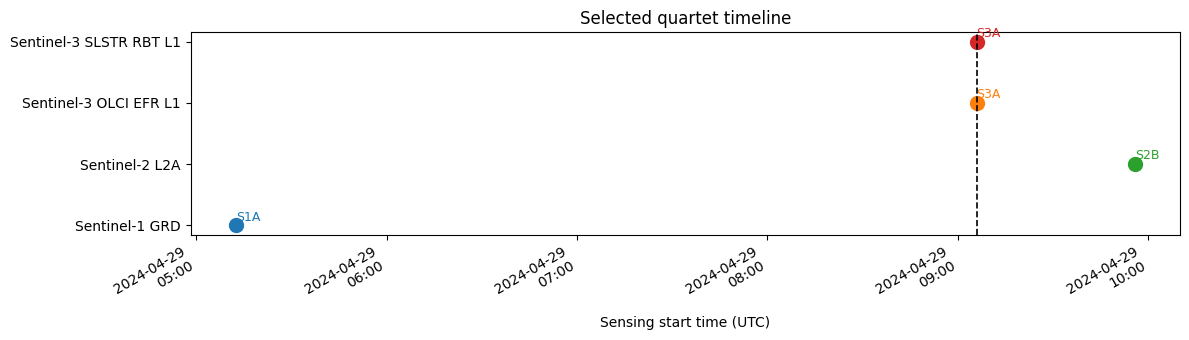

In [7]:
def build_footprint_map(quartet_df: pd.DataFrame, aoi_wkt: str) -> folium.Map:
    aoi_geom = shapely_wkt.loads(aoi_wkt)
    center = [aoi_geom.centroid.y, aoi_geom.centroid.x]
    fmap = folium.Map(location=center, zoom_start=8, tiles="CartoDB positron")

    folium.GeoJson(
        mapping(aoi_geom),
        name="AOI",
        style_function=lambda _feature: {
            "color": "#111111",
            "weight": 2,
            "fillOpacity": 0.05,
        },
    ).add_to(fmap)

    shapes = [aoi_geom]
    for row in quartet_df.itertuples(index=False):
        footprint = row.GeoFootprint if isinstance(row.GeoFootprint, dict) else json.loads(row.GeoFootprint)
        geom = shape(footprint)
        shapes.append(geom)
        color = SENSOR_CONFIG[row.sensor_key]["color"]
        folium.GeoJson(
            footprint,
            name=row.sensor_label,
            tooltip=f"{row.sensor_label}: {row.Name}",
            style_function=lambda _feature, color=color: {
                "color": color,
                "weight": 2,
                "fillColor": color,
                "fillOpacity": 0.18,
            },
        ).add_to(fmap)

    bounds = unary_union(shapes).bounds
    fmap.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])
    folium.LayerControl(collapsed=False).add_to(fmap)
    return fmap


def plot_quartet_timeline(quartet_df: pd.DataFrame, metrics: dict) -> None:
    fig, ax = plt.subplots(figsize=(12, 3.5))
    for idx, sensor_key in enumerate(SENSOR_ORDER):
        row = quartet_df.loc[quartet_df["sensor_key"] == sensor_key].iloc[0]
        color = SENSOR_CONFIG[sensor_key]["color"]
        ax.scatter(row["start_time"].to_pydatetime(), idx, s=100, color=color)
        ax.text(
            row["start_time"].to_pydatetime(),
            idx + 0.08,
            row["Name"].split("_")[0],
            fontsize=9,
            color=color,
        )

    ax.axvline(metrics["median_time"].to_pydatetime(warn=False), color="black", linestyle="--", linewidth=1.2)
    ax.set_yticks(range(len(SENSOR_ORDER)))
    ax.set_yticklabels([SENSOR_CONFIG[key]["label"] for key in SENSOR_ORDER])
    ax.set_xlabel("Sensing start time (UTC)")
    ax.set_title("Selected quartet timeline")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


footprint_map = build_footprint_map(selected_quartet_df, aoi_wkt)
plot_quartet_timeline(selected_quartet_df, selected_metrics)
footprint_map

## Repo Preview Boundary
The committed notebook keeps executed outputs through matching, diagnostics, and grid planning so GitHub shows the workflow directly.
The download, export, and optional tensor-packaging cells are intentionally left unexecuted in the committed preview because they require live product downloads and the full raster stack.

Everything after this point is still part of the notebook design and has been checked as code, but you should think of it as the "live execution" half of the workflow.

## Download The Selected Products

This cell is the hand-off from planning to execution.

What it does:
- downloads exactly the four products chosen by the matcher,
- keeps them in a dedicated download directory,
- uses `phidown` directly so the notebook stays reproducible.

Run this only after you are satisfied with the search tables, quartet report, and footprint diagnostics.

In [8]:
downloader = CopernicusDataSearcher()
for row in selected_quartet_df.itertuples(index=False):
    print(f"Downloading {row.sensor_label}: {row.Name}")
    downloader.download_product(
        eo_product_name=row.Name,
        output_dir=str(download_path),
        mode="fast",
    )

Output directory: /home/theodor/Projects/phidown/notebooks/data/9_s1_s2_s3_thor_workflow
Mode: fast


Downloading: 3.29GB [00:32, 53.8MB/s]                    


Output directory: /home/theodor/Projects/phidown/notebooks/data/9_s1_s2_s3_thor_workflow
Mode: fast


Downloading: 1.38GB [00:37, 12.2MB/s]                  


Output directory: /home/theodor/Projects/phidown/notebooks/data/9_s1_s2_s3_thor_workflow
Mode: fast


Downloading: 1.26GB [00:29, 15.8MB/s]                  


Output directory: /home/theodor/Projects/phidown/notebooks/data/9_s1_s2_s3_thor_workflow
Mode: fast


Downloading: 604MB [00:19, 8.18MB/s]                   


## Grid Strategy And Alignment Self-Check

This section defines what "pixel aligned" means in this notebook.

The approach is:
1. derive one projected CRS from the AOI centroid,
2. snap the AOI bounds to the coarsest requested resolution,
3. build one family of nested grids that all share the same origin,
4. verify that every resolution is an integer multiple of the finest grid.

Important interpretation:
- the outputs are not forced onto one single pixel size,
- instead they are aligned as nested grids with one common origin and CRS,
- so `10 m`, `240 m`, `480 m`, and `960 m` products are still pixel aligned across resolutions.

In [9]:
def derive_local_utm_crs(aoi_wkt: str) -> CRS:
    geom = shapely_wkt.loads(aoi_wkt)
    lon = geom.centroid.x
    lat = geom.centroid.y
    zone = int((lon + 180) // 6) + 1
    epsg = 32600 + zone if lat >= 0 else 32700 + zone
    return CRS.from_epsg(epsg)


def snap_bounds(minx: float, miny: float, maxx: float, maxy: float, snap_step: float) -> tuple[float, float, float, float]:
    return (
        math.floor(minx / snap_step) * snap_step,
        math.floor(miny / snap_step) * snap_step,
        math.ceil(maxx / snap_step) * snap_step,
        math.ceil(maxy / snap_step) * snap_step,
    )


def build_target_lonlat(grid: dict) -> tuple[np.ndarray, np.ndarray]:
    rows, cols = np.meshgrid(
        np.arange(grid["height"]),
        np.arange(grid["width"]),
        indexing="ij",
    )
    xs, ys = rasterio.transform.xy(grid["transform"], rows, cols, offset="center")
    xs = np.asarray(xs)
    ys = np.asarray(ys)
    to_geographic = Transformer.from_crs(grid["crs"], "EPSG:4326", always_xy=True)
    lons, lats = to_geographic.transform(xs, ys)
    return np.asarray(lons, dtype=np.float32), np.asarray(lats, dtype=np.float32)


def build_aoi_mask(grid: dict) -> np.ndarray:
    return geometry_mask(
        [mapping(grid["aoi_target"])],
        out_shape=(grid["height"], grid["width"]),
        transform=grid["transform"],
        invert=True,
    )


def build_aligned_grid_family(aoi_wkt: str, resolution_map: dict[str, int]) -> dict[str, dict]:
    aoi_geom = shapely_wkt.loads(aoi_wkt)
    target_crs = derive_local_utm_crs(aoi_wkt)
    to_target = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True).transform
    aoi_target = shapely_transform(to_target, aoi_geom)
    max_resolution = max(resolution_map.values())
    minx, miny, maxx, maxy = snap_bounds(*aoi_target.bounds, snap_step=max_resolution)

    # Make the grid square by extending the shorter dimension.
    extent_x = maxx - minx
    extent_y = maxy - miny
    max_extent = max(extent_x, extent_y)
    maxx = minx + max_extent  # extend right
    miny = maxy - max_extent  # extend down

    grid_family = {}
    for label, resolution_m in resolution_map.items():
        width_f = (maxx - minx) / resolution_m
        height_f = (maxy - miny) / resolution_m
        if abs(width_f - round(width_f)) > 1e-6 or abs(height_f - round(height_f)) > 1e-6:
            raise ValueError(
                f"Snapped AOI bounds are not divisible by resolution {resolution_m} m for {label}"
            )
        width = max(1, int(round(width_f)))
        height = max(1, int(round(height_f)))
        transform = from_origin(minx, maxy, resolution_m, resolution_m)
        grid_family[label] = {
            "label": label,
            "crs": target_crs,
            "transform": transform,
            "width": width,
            "height": height,
            "resolution_m": resolution_m,
            "aoi_target": aoi_target,
            "bounds_target": (minx, miny, maxx, maxy),
        }
        # rotated polygon
        # grid_family[label]["mask"] = build_aoi_mask(grid_family[label])
        # axis aligned
        grid_family[label]["mask"] = np.ones((height, width), dtype=bool)
        grid_family[label]["target_lons"], grid_family[label]["target_lats"] = (
            build_target_lonlat(grid_family[label])
        )
    return grid_family


def verify_grid_family(grid_family: dict[str, dict]) -> pd.DataFrame:
    rows = []
    for label, grid in grid_family.items():
        rows.append(
            {
                "modality": label,
                "resolution_m": grid["resolution_m"],
                "width": grid["width"],
                "height": grid["height"],
                "crs": str(grid["crs"]),
                "origin_x": grid["transform"].c,
                "origin_y": grid["transform"].f,
            }
        )
    verification_df = pd.DataFrame(rows).sort_values("resolution_m").reset_index(drop=True)
    assert verification_df["crs"].nunique() == 1, "Grid family does not share a single CRS"
    assert verification_df["origin_x"].nunique() == 1, "Grid family does not share a single X origin"
    assert verification_df["origin_y"].nunique() == 1, "Grid family does not share a single Y origin"
    finest_resolution = verification_df["resolution_m"].min()
    for value in verification_df["resolution_m"]:
        ratio = value / finest_resolution
        assert abs(ratio - round(ratio)) < 1e-9, "Grid resolutions are not integer multiples of the finest GSD"
    return verification_df


grid_family = build_aligned_grid_family(aoi_wkt, resolution_map)
grid_family_df = verify_grid_family(grid_family)
display(grid_family_df)

,modality,resolution_m,width,height,crs,origin_x,origin_y
0,S1GRD,10,2688,2688,EPSG:32633,279360.0,4656000.0
1,S2L2A,10,2688,2688,EPSG:32633,279360.0,4656000.0
2,S3OLCI,240,112,112,EPSG:32633,279360.0,4656000.0
3,S3SLSTR_REFL,480,56,56,EPSG:32633,279360.0,4656000.0
4,S3SLSTR_BT,960,28,28,EPSG:32633,279360.0,4656000.0


## Raster, Swath, And Export Helpers

This is the most implementation-heavy section, so read it by responsibility instead of line by line.

Helper groups:
- regular raster helpers: write GeoTIFFs, reproject Sentinel-1 and Sentinel-2, preserve band names.
- Sentinel-1 helpers: pick a sensible co-polarisation pair and geocode the measurement TIFFs.
- Sentinel-2 helpers: locate the requested L2A bands across the `10 m`, `20 m`, and `60 m` folders.
- OLCI helpers: convert Level-1 radiance to reflectance using tie-point geometry and instrument data.
- SLSTR helpers: load reflectance and brightness temperature from the two native nadir grids.
- swath helpers: crop swaths near the AOI and resample them to the aligned projected grids.

This is also the section where we were most suspicious during audit, so the swath resampling path was explicitly rechecked with synthetic tests.

In [10]:
S1_PRIMARY_PAIR = ("VV", "VH")
S1_ALTERNATE_PAIR = ("HH", "HV")
S1_POLARIZATION_PRIORITY = ("VV", "VH", "HH", "HV")
S2_BAND_RESOLUTION_M = {
    "B01": 60,
    "B02": 10,
    "B03": 10,
    "B04": 10,
    "B05": 20,
    "B06": 20,
    "B07": 20,
    "B08": 10,
    "B8A": 20,
    "B09": 60,
    "B11": 20,
    "B12": 20,
}
OLCI_BAND_NAMES = [f"Oa{i:02d}_reflectance" for i in range(1, 22)]
SLSTR_REFLECTANCE_BANDS = [f"S{i}_reflectance" for i in range(1, 7)]
SLSTR_BT_BANDS = [f"S{i}_BT" for i in range(7, 10)]


def resolve_product_dir(product_name: str, base_dir: Path) -> Path:
    candidate = base_dir / product_name
    if candidate.exists():
        return candidate
    matches = sorted(base_dir.glob(f"{product_name}*"))
    if len(matches) == 1:
        return matches[0]
    raise FileNotFoundError(f"Unable to resolve product directory for {product_name}")


def write_multiband_geotiff(array: np.ndarray, dst_path: Path, grid: dict, band_names: list[str]) -> Path:
    data = np.asarray(array, dtype=np.float32)
    if data.ndim == 2:
        data = data[np.newaxis, :, :]
    if data.shape[0] != len(band_names):
        raise ValueError(
            f"Band name count {len(band_names)} does not match data band count {data.shape[0]}"
        )
    profile = {
        "driver": "GTiff",
        "height": grid["height"],
        "width": grid["width"],
        "count": data.shape[0],
        "dtype": "float32",
        "crs": grid["crs"],
        "transform": grid["transform"],
        "nodata": np.nan,
        "compress": "deflate",
    }
    with rasterio.open(dst_path, "w", **profile) as dst:
        dst.write(data)
        for index, name in enumerate(band_names, start=1):
            dst.set_band_description(index, name)
    return dst_path


def raster_to_grid_array(
    src_path: Path,
    grid: dict,
    *,
    aoi_mask: np.ndarray,
    resampling: Resampling = Resampling.bilinear,
) -> tuple[np.ndarray, list[str]]:
    with rasterio.open(src_path) as src:
        destination = np.full((src.count, grid["height"], grid["width"]), np.nan, dtype=np.float32)
        for band in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, band),
                destination=destination[band - 1],
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=grid["transform"],
                dst_crs=grid["crs"],
                dst_nodata=np.nan,
                resampling=resampling,
            )
        destination = np.where(aoi_mask[np.newaxis, :, :], destination, np.nan)
        band_names = [name or f"band_{idx}" for idx, name in enumerate(src.descriptions, start=1)]
    return destination, band_names


def align_raster_files_to_grid(
    src_items: list[tuple[str, Path]],
    dst_path: Path,
    grid: dict,
    *,
    aoi_mask: np.ndarray,
    resampling: Resampling = Resampling.bilinear,
) -> Path:
    if not src_items:
        raise ValueError("No source rasters were provided for alignment")
    arrays = []
    band_names = []
    for band_name, src_path in src_items:
        with rasterio.open(src_path) as src:
            destination = np.full((grid["height"], grid["width"]), np.nan, dtype=np.float32)
            reproject(
                source=rasterio.band(src, 1),
                destination=destination,
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=grid["transform"],
                dst_crs=grid["crs"],
                dst_nodata=np.nan,
                resampling=resampling,
            )
        destination = np.where(aoi_mask, destination, np.nan)
        arrays.append(destination)
        band_names.append(band_name)
    stack = np.stack(arrays, axis=0)
    return write_multiband_geotiff(stack, dst_path, grid, band_names)


def warp_s1_measurement_to_epsg4326(
    src_tiff: Path,
    dst_tiff: Path,
    *,
    resampling: Resampling = Resampling.bilinear,
) -> Path:
    with rasterio.Env(GDAL_GCP_USE_OK="YES"):
        with rasterio.open(src_tiff) as src:
            gcps, gcp_crs = src.gcps
            if src.crs:
                src_crs = src.crs
                src_transform = src.transform
            elif gcps and gcp_crs:
                src_crs = gcp_crs
                src_transform = from_gcps(gcps)
            else:
                raise ValueError("Source raster has neither a CRS nor GCPs")

            bounds = array_bounds(src.height, src.width, src_transform)
            dst_crs = "EPSG:4326"
            dst_transform, dst_width, dst_height = calculate_default_transform(
                src_crs,
                dst_crs,
                src.width,
                src.height,
                *bounds,
            )

            profile = src.profile.copy()
            for key in ("affine", "transform", "blockxsize", "blockysize", "tiled"):
                profile.pop(key, None)
            profile.update(
                driver="GTiff",
                height=dst_height,
                width=dst_width,
                transform=dst_transform,
                crs=dst_crs,
                count=src.count,
                dtype=src.dtypes[0],
                compress="deflate",
            )

            with rasterio.open(dst_tiff, "w", **profile) as dst:
                for band in range(1, src.count + 1):
                    reproject(
                        source=rasterio.band(src, band),
                        destination=rasterio.band(dst, band),
                        src_transform=src_transform,
                        src_crs=src_crs,
                        dst_transform=dst_transform,
                        dst_crs=dst_crs,
                        resampling=resampling,
                    )
    return dst_tiff


def choose_s1_measurement_tiffs(product_dir: Path) -> list[tuple[str, Path]]:
    measurement_dir = product_dir / "measurement"
    if not measurement_dir.exists():
        raise FileNotFoundError(f"Measurement directory not found: {measurement_dir}")
    files = sorted(measurement_dir.glob("*.tif*"))
    if not files:
        raise FileNotFoundError(f"No measurement TIFF found in {measurement_dir}")

    available = {}
    for path in files:
        lower_name = path.name.lower()
        if "geocoded" in lower_name:
            continue
        for polarization in S1_POLARIZATION_PRIORITY:
            token = f"-{polarization.lower()}-"
            if token in lower_name:
                available.setdefault(polarization, path)

    if set(S1_PRIMARY_PAIR).issubset(available):
        order = list(S1_PRIMARY_PAIR)
    elif set(S1_ALTERNATE_PAIR).issubset(available):
        order = list(S1_ALTERNATE_PAIR)
    else:
        order = [polarization for polarization in S1_POLARIZATION_PRIORITY if polarization in available]

    if not order:
        raise FileNotFoundError(f"Unable to determine any S1 measurement TIFFs in {measurement_dir}")
    return [(polarization, available[polarization]) for polarization in order]


def find_s2_band_path(product_dir: Path, band_name: str) -> Path:
    resolution_m = S2_BAND_RESOLUTION_M[band_name]
    patterns = [
        f"GRANULE/*/IMG_DATA/R{resolution_m}m/*_{band_name}_{resolution_m}m.jp2",
        f"GRANULE/*/IMG_DATA/*_{band_name}_{resolution_m}m.jp2",
        f"GRANULE/*/IMG_DATA/*_{band_name}.jp2",
    ]
    for pattern in patterns:
        matches = sorted(product_dir.glob(pattern))
        if matches:
            return matches[0]
    raise FileNotFoundError(f"Unable to locate Sentinel-2 band {band_name} in {product_dir}")


def interp_tie_points(tie_values: np.ndarray, target_shape: tuple[int, int]) -> np.ndarray:
    tie_values = np.asarray(tie_values, dtype=np.float32)
    src_rows = np.linspace(0.0, 1.0, tie_values.shape[0], dtype=np.float64)
    src_cols = np.linspace(0.0, 1.0, tie_values.shape[1], dtype=np.float64)
    dst_rows = np.linspace(0.0, 1.0, target_shape[0], dtype=np.float64)
    dst_cols = np.linspace(0.0, 1.0, target_shape[1], dtype=np.float64)

    row_interpolated = np.empty((target_shape[0], tie_values.shape[1]), dtype=np.float32)
    for col_idx in range(tie_values.shape[1]):
        row_interpolated[:, col_idx] = np.interp(dst_rows, src_rows, tie_values[:, col_idx].astype(np.float64))

    full = np.empty(target_shape, dtype=np.float32)
    for row_idx in range(target_shape[0]):
        full[row_idx, :] = np.interp(dst_cols, src_cols, row_interpolated[row_idx, :].astype(np.float64))
    return full


def radiance_to_reflectance(radiance: np.ndarray, solar_irradiance: np.ndarray, cos_sza: np.ndarray) -> np.ndarray:
    denominator = np.clip(np.asarray(solar_irradiance, dtype=np.float32) * np.asarray(cos_sza, dtype=np.float32), 1e-6, None)
    reflectance = np.pi * np.asarray(radiance, dtype=np.float32) / denominator
    return np.clip(reflectance, 0.0, 2.0).astype(np.float32)


def load_olci_reflectance(scene_dir: str | Path) -> tuple[np.ndarray, list[str]]:
    scene_dir = Path(scene_dir)
    with xr.open_dataset(scene_dir / "Oa01_radiance.nc", engine="netcdf4", mask_and_scale=True) as sample:
        target_shape = sample["Oa01_radiance"].values.shape

    with xr.open_dataset(scene_dir / "tie_geometries.nc", engine="netcdf4", mask_and_scale=True) as ds_geo:
        sza_full = interp_tie_points(ds_geo["SZA"].values.astype(np.float32), target_shape)
    cos_sza = np.clip(np.cos(np.deg2rad(sza_full)), 0.01, None).astype(np.float32)

    with xr.open_dataset(scene_dir / "instrument_data.nc", engine="netcdf4", mask_and_scale=False) as instr:
        solar_flux = instr["solar_flux"].values.astype(np.float32)
        detector_index = instr["detector_index"].values.astype(np.intp)
    detector_index_safe = np.clip(detector_index, 0, solar_flux.shape[1] - 1)

    arrays = []
    for index in range(1, 22):
        variable_name = f"Oa{index:02d}_radiance"
        with xr.open_dataset(scene_dir / f"{variable_name}.nc", engine="netcdf4", mask_and_scale=True) as ds:
            radiance = ds[variable_name].values.astype(np.float32)
        irradiance = solar_flux[index - 1][detector_index_safe]
        reflectance = radiance_to_reflectance(radiance, irradiance, cos_sza)
        reflectance = np.where(detector_index >= 0, reflectance, np.nan).astype(np.float32)
        arrays.append(reflectance)

    return np.stack(arrays, axis=0), OLCI_BAND_NAMES


def load_olci_geo(scene_dir: str | Path) -> tuple[np.ndarray, np.ndarray]:
    scene_dir = Path(scene_dir)
    with xr.open_dataset(scene_dir / "Oa01_radiance.nc", engine="netcdf4", mask_and_scale=True) as sample:
        target_shape = sample["Oa01_radiance"].values.shape
    with xr.open_dataset(scene_dir / "tie_geo_coordinates.nc", engine="netcdf4", mask_and_scale=True) as ds:
        latitude = interp_tie_points(ds["latitude"].values.astype(np.float32), target_shape)
        longitude = interp_tie_points(ds["longitude"].values.astype(np.float32), target_shape)
    return latitude, longitude


def load_slstr_reflectance(scene_dir: str | Path) -> np.ndarray:
    scene_dir = Path(scene_dir)
    with xr.open_dataset(scene_dir / "indices_an.nc", engine="netcdf4", mask_and_scale=True) as indices_ds:
        detectors = indices_ds["detector_an"].values.astype(np.float32)
    valid_mask = np.isfinite(detectors) & (detectors >= 0)
    detector_index = np.clip(np.nan_to_num(detectors, nan=0.0).astype(np.intp), 0, None)

    with xr.open_dataset(scene_dir / "S1_radiance_an.nc", engine="netcdf4", mask_and_scale=True) as sample:
        target_shape = sample["S1_radiance_an"].values.shape
    with xr.open_dataset(scene_dir / "geometry_tn.nc", engine="netcdf4", mask_and_scale=True) as geometry_ds:
        sza_full = interp_tie_points(geometry_ds["solar_zenith_tn"].values.astype(np.float32), target_shape)
    cos_sza = np.clip(np.cos(np.deg2rad(sza_full)), 0.01, None).astype(np.float32)

    arrays = []
    for index in range(1, 7):
        radiance_name = f"S{index}_radiance_an"
        irradiance_name = f"S{index}_solar_irradiance_an"
        quality_path = scene_dir / f"S{index}_quality_an.nc"
        if not quality_path.exists():
            raise FileNotFoundError(f"Missing SLSTR quality file required for reflectance conversion: {quality_path}")
        with xr.open_dataset(scene_dir / f"{radiance_name}.nc", engine="netcdf4", mask_and_scale=True) as ds:
            radiance = ds[radiance_name].values.astype(np.float32)
        with xr.open_dataset(quality_path, engine="netcdf4", mask_and_scale=True) as qds:
            irradiance_per_detector = qds[irradiance_name].values.astype(np.float32)
        irradiance = irradiance_per_detector[np.clip(detector_index, 0, len(irradiance_per_detector) - 1)]
        reflectance = radiance_to_reflectance(radiance, irradiance, cos_sza)
        reflectance = np.where(valid_mask, reflectance, np.nan).astype(np.float32)
        arrays.append(reflectance)
    return np.stack(arrays, axis=0)


def load_slstr_bt(scene_dir: str | Path) -> np.ndarray:
    scene_dir = Path(scene_dir)
    arrays = []
    for index in range(7, 10):
        variable_name = f"S{index}_BT_in"
        with xr.open_dataset(scene_dir / f"{variable_name}.nc", engine="netcdf4", mask_and_scale=True) as ds:
            arrays.append(ds[variable_name].values.astype(np.float32))
    return np.stack(arrays, axis=0)


def load_slstr_geo(scene_dir: str | Path) -> tuple[np.ndarray | None, np.ndarray | None, np.ndarray | None, np.ndarray | None]:
    scene_dir = Path(scene_dir)
    lat_an = lon_an = lat_in = lon_in = None
    an_path = scene_dir / "geodetic_an.nc"
    if an_path.exists():
        with xr.open_dataset(an_path, engine="netcdf4", mask_and_scale=True) as ds:
            lat_an = ds["latitude_an"].values.astype(np.float32)
            lon_an = ds["longitude_an"].values.astype(np.float32)
    in_path = scene_dir / "geodetic_in.nc"
    if in_path.exists():
        with xr.open_dataset(in_path, engine="netcdf4", mask_and_scale=True) as ds:
            lat_in = ds["latitude_in"].values.astype(np.float32)
            lon_in = ds["longitude_in"].values.astype(np.float32)
    return lat_an, lon_an, lat_in, lon_in


def crop_swath_to_bbox(
    data: np.ndarray,
    lons: np.ndarray,
    lats: np.ndarray,
    bounds: tuple[float, float, float, float],
    *,
    pad_degrees: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    minx, miny, maxx, maxy = bounds
    valid = (
        np.isfinite(lons)
        & np.isfinite(lats)
        & (lons >= minx - pad_degrees)
        & (lons <= maxx + pad_degrees)
        & (lats >= miny - pad_degrees)
        & (lats <= maxy + pad_degrees)
    )
    if not np.any(valid):
        return data, lons, lats
    row_idx, col_idx = np.where(valid)
    row_slice = slice(int(row_idx.min()), int(row_idx.max()) + 1)
    col_slice = slice(int(col_idx.min()), int(col_idx.max()) + 1)
    if data.ndim == 3:
        data = data[:, row_slice, col_slice]
    else:
        data = data[row_slice, col_slice]
    return data, lons[row_slice, col_slice], lats[row_slice, col_slice]


def resample_swath_stack_to_grid(
    data: np.ndarray,
    lons: np.ndarray,
    lats: np.ndarray,
    dst_path: Path,
    grid: dict,
    *,
    aoi_mask: np.ndarray,
    band_names: list[str],
    radius_of_influence_m: float,
) -> Path:
    values = np.asarray(data, dtype=np.float32)
    if values.ndim == 2:
        values = values[np.newaxis, :, :]
    lons = np.asarray(lons, dtype=np.float32)
    lats = np.asarray(lats, dtype=np.float32)
    if values.shape[-2:] != lons.shape or lons.shape != lats.shape:
        raise ValueError(
            f"Swath data shape {values.shape[-2:]} is inconsistent with lon/lat shapes {lons.shape} and {lats.shape}"
        )
    source_def = geometry.SwathDefinition(lons=lons, lats=lats)
    target_def = geometry.SwathDefinition(lons=grid["target_lons"], lats=grid["target_lats"])
    arrays = []
    for band in values:
        resampled = kd_tree.resample_nearest(
            source_def,
            band,
            target_def,
            radius_of_influence=radius_of_influence_m,
            fill_value=np.nan,
        )
        # pyresample may return a flat vector for swath targets, so reshape explicitly.
        resampled = np.asarray(np.ma.filled(resampled, np.nan), dtype=np.float32).reshape(
            grid["height"], grid["width"]
        )
        arrays.append(resampled)
    stack = np.stack(arrays, axis=0)
    stack = np.where(aoi_mask[np.newaxis, :, :], stack, np.nan)
    return write_multiband_geotiff(stack, dst_path, grid, band_names)


def build_manifest_rows(export_paths: dict[str, Path], resolution_map: dict[str, int]) -> list[dict]:
    rows = []
    for modality, path in export_paths.items():
        with rasterio.open(path) as src:
            rows.append(
                {
                    "modality": modality,
                    "path": str(path),
                    "resolution_m": resolution_map[modality],
                    "band_count": src.count,
                    "width": src.width,
                    "height": src.height,
                    "crs": str(src.crs),
                    "band_names": list(src.descriptions),
                }
            )
    return rows


def stretch_rgb(stack: np.ndarray) -> np.ndarray:
    rgb = np.moveaxis(np.asarray(stack, dtype=np.float32), 0, -1)
    out = np.zeros_like(rgb, dtype=np.float32)
    for channel in range(rgb.shape[-1]):
        band = rgb[..., channel]
        finite = band[np.isfinite(band)]
        if finite.size == 0:
            continue
        lo, hi = np.percentile(finite, [2, 98])
        scale = hi - lo if hi > lo else 1.0
        out[..., channel] = np.clip((band - lo) / scale, 0.0, 1.0)
    return np.nan_to_num(out)

## Export Modality-Specific GeoTIFFs

This cell performs the full modality export in a fixed order.

Step by step:
1. resolve the downloaded product folders,
2. export Sentinel-1 as a small multi-band stack using the preferred polarisation pair,
3. export all requested Sentinel-2 bands onto the aligned 10 m grid,
4. load OLCI Level-1 radiances, convert to reflectance, crop near the AOI, and export at 240 m,
5. load SLSTR reflectance and brightness temperatures, crop them separately, and export them at 480 m and 960 m,
6. optionally fuse Sentinel-3 into one 240 m stack,
7. write a machine-readable manifest.

This is the cell that writes the modality-specific GeoTIFF outputs used by downstream THOR or terratorch-style pipelines.

In [11]:
product_dirs = {
    row.sensor_key: resolve_product_dir(row.Name, download_path)
    for row in selected_quartet_df.itertuples(index=False)
}

export_paths: dict[str, Path] = {}
scratch_path = output_path / "scratch"
scratch_path.mkdir(parents=True, exist_ok=True)
aoi_bounds_geo = shapely_wkt.loads(aoi_wkt).bounds

s1_src_items = []
for polarization, src_tiff in choose_s1_measurement_tiffs(product_dirs["s1_grd"]):
    geocoded_tiff = scratch_path / f"{src_tiff.stem}_epsg4326.tif"
    warp_s1_measurement_to_epsg4326(src_tiff, geocoded_tiff)
    s1_src_items.append((polarization, geocoded_tiff))
export_paths["S1GRD"] = align_raster_files_to_grid(
    s1_src_items,
    output_path / f"s1_grd_{s1_target_resolution_m}m.tif",
    grid_family["S1GRD"],
    aoi_mask=grid_family["S1GRD"]["mask"],
    resampling=Resampling.bilinear,
)

s2_src_items = [
    (band_name, find_s2_band_path(product_dirs["s2_l2a"], band_name))
    for band_name in s2_band_order
]
export_paths["S2L2A"] = align_raster_files_to_grid(
    s2_src_items,
    output_path / f"s2_l2a_{s2_target_resolution_m}m.tif",
    grid_family["S2L2A"],
    aoi_mask=grid_family["S2L2A"]["mask"],
    resampling=Resampling.bilinear,
)

olci_data, olci_band_names = load_olci_reflectance(product_dirs["s3_olci_l1"])
olci_lats, olci_lons = load_olci_geo(product_dirs["s3_olci_l1"])
olci_data, olci_lons, olci_lats = crop_swath_to_bbox(
    olci_data,
    olci_lons,
    olci_lats,
    aoi_bounds_geo,
    pad_degrees=swath_pad_degrees,
)
export_paths["S3OLCI"] = resample_swath_stack_to_grid(
    olci_data,
    olci_lons,
    olci_lats,
    output_path / f"s3_olci_{olci_target_resolution_m}m.tif",
    grid_family["S3OLCI"],
    aoi_mask=grid_family["S3OLCI"]["mask"],
    band_names=olci_band_names,
    radius_of_influence_m=swath_radius_of_influence_m,
)

slstr_refl = load_slstr_reflectance(product_dirs["s3_slstr_l1"])
slstr_bt = load_slstr_bt(product_dirs["s3_slstr_l1"])
lat_an, lon_an, lat_in, lon_in = load_slstr_geo(product_dirs["s3_slstr_l1"])
if lat_an is None or lon_an is None or lat_in is None or lon_in is None:
    raise FileNotFoundError("SLSTR geolocation files are incomplete; expected both geodetic_an.nc and geodetic_in.nc")

slstr_refl, lon_an, lat_an = crop_swath_to_bbox(
    slstr_refl,
    lon_an,
    lat_an,
    aoi_bounds_geo,
    pad_degrees=swath_pad_degrees,
)
slstr_bt, lon_in, lat_in = crop_swath_to_bbox(
    slstr_bt,
    lon_in,
    lat_in,
    aoi_bounds_geo,
    pad_degrees=swath_pad_degrees,
)
export_paths["S3SLSTR_REFL"] = resample_swath_stack_to_grid(
    slstr_refl,
    lon_an,
    lat_an,
    output_path / f"s3_slstr_reflectance_{slstr_reflectance_resolution_m}m.tif",
    grid_family["S3SLSTR_REFL"],
    aoi_mask=grid_family["S3SLSTR_REFL"]["mask"],
    band_names=SLSTR_REFLECTANCE_BANDS,
    radius_of_influence_m=swath_radius_of_influence_m,
)
export_paths["S3SLSTR_BT"] = resample_swath_stack_to_grid(
    slstr_bt,
    lon_in,
    lat_in,
    output_path / f"s3_slstr_bt_{slstr_bt_resolution_m}m.tif",
    grid_family["S3SLSTR_BT"],
    aoi_mask=grid_family["S3SLSTR_BT"]["mask"],
    band_names=SLSTR_BT_BANDS,
    radius_of_influence_m=swath_radius_of_influence_m,
)

if export_s3_combined_240m:
    olci_array, olci_band_names = raster_to_grid_array(
        export_paths["S3OLCI"],
        grid_family["S3COMBINED"],
        aoi_mask=grid_family["S3COMBINED"]["mask"],
        resampling=Resampling.nearest,
    )
    slstr_refl_array, slstr_refl_band_names = raster_to_grid_array(
        export_paths["S3SLSTR_REFL"],
        grid_family["S3COMBINED"],
        aoi_mask=grid_family["S3COMBINED"]["mask"],
        resampling=Resampling.bilinear,
    )
    slstr_bt_array, slstr_bt_band_names = raster_to_grid_array(
        export_paths["S3SLSTR_BT"],
        grid_family["S3COMBINED"],
        aoi_mask=grid_family["S3COMBINED"]["mask"],
        resampling=Resampling.bilinear,
    )
    s3_combined = np.concatenate([olci_array, slstr_refl_array, slstr_bt_array], axis=0)
    export_paths["S3COMBINED"] = write_multiband_geotiff(
        s3_combined,
        output_path / f"s3_combined_{s3_combined_resolution_m}m.tif",
        grid_family["S3COMBINED"],
        olci_band_names + slstr_refl_band_names + slstr_bt_band_names,
    )

manifest_rows = build_manifest_rows(export_paths, resolution_map)
export_manifest_df = pd.DataFrame(manifest_rows)
export_manifest_csv = output_path / "export_manifest.csv"
export_manifest_json = output_path / "export_manifest.json"
export_manifest_df.to_csv(export_manifest_csv, index=False)

workflow_summary = {
    "aoi_wkt": aoi_wkt,
    "start_date": start_date,
    "end_date": end_date,
    "selected_products": quartet_summary_df.to_dict(orient="records"),
    "export_files": manifest_rows,
}
export_manifest_json.write_text(json.dumps(workflow_summary, indent=2, default=str))

print("Exports written to:", output_path)
display(export_manifest_df)

/home/theodor/Projects/phidown/.venv/lib/python3.13/site-packages/xarray/namedarray/core.py:261: UserWarning: Duplicate dimension names present: dimensions {'bands'} appear more than once in dims=('bands', 'bands'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
/home/theodor/Projects/phidown/.venv/lib/python3.13/site-packages/xarray/namedarray/core.py:261: UserWarning: Duplicate dimension names present: dimensions {'bands'} appear more than once in dims=('bands', 'bands'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, a

Exports written to: /home/theodor/Projects/phidown/notebooks/out/9_s1_s2_s3_thor_workflow


,modality,path,resolution_m,band_count,width,height,crs,band_names
0,S1GRD,/home/theodor/Projects/phidown/notebooks/out/9_s1_s2_s3_thor_workflow/s1_grd_10m.tif,10,2,2688,2688,EPSG:32633,"[VV, VH]"
1,S2L2A,/home/theodor/Projects/phidown/notebooks/out/9_s1_s2_s3_thor_workflow/s2_l2a_10m.tif,10,12,2688,2688,EPSG:32633,"[B01, B02, B03, B04, B05, B06, B07, B08, B8A, B09, B11, B12]"
2,S3OLCI,/home/theodor/Projects/phidown/notebooks/out/9_s1_s2_s3_thor_workflow/s3_olci_240m.tif,240,21,112,112,EPSG:32633,"[Oa01_reflectance, Oa02_reflectance, Oa03_reflectance, Oa04_reflectance, Oa05_reflectance, Oa06_reflectance, Oa07_re..."
3,S3SLSTR_REFL,/home/theodor/Projects/phidown/notebooks/out/9_s1_s2_s3_thor_workflow/s3_slstr_reflectance_480m.tif,480,6,56,56,EPSG:32633,"[S1_reflectance, S2_reflectance, S3_reflectance, S4_reflectance, S5_reflectance, S6_reflectance]"
4,S3SLSTR_BT,/home/theodor/Projects/phidown/notebooks/out/9_s1_s2_s3_thor_workflow/s3_slstr_bt_960m.tif,960,3,28,28,EPSG:32633,"[S7_BT, S8_BT, S9_BT]"


## Preview The Exported ROI

Once the export cell has run, this section gives you one quick visual sanity check:
- a Sentinel-1 intensity view,
- a Sentinel-2 RGB view,
- an OLCI RGB view,
- an SLSTR reflectance view,
- an SLSTR thermal view,
- and a text panel summarising the exported file names.

The purpose is not publication-quality visualisation. It is a quick confirmation that the exported stacks are non-empty and geographically sensible.

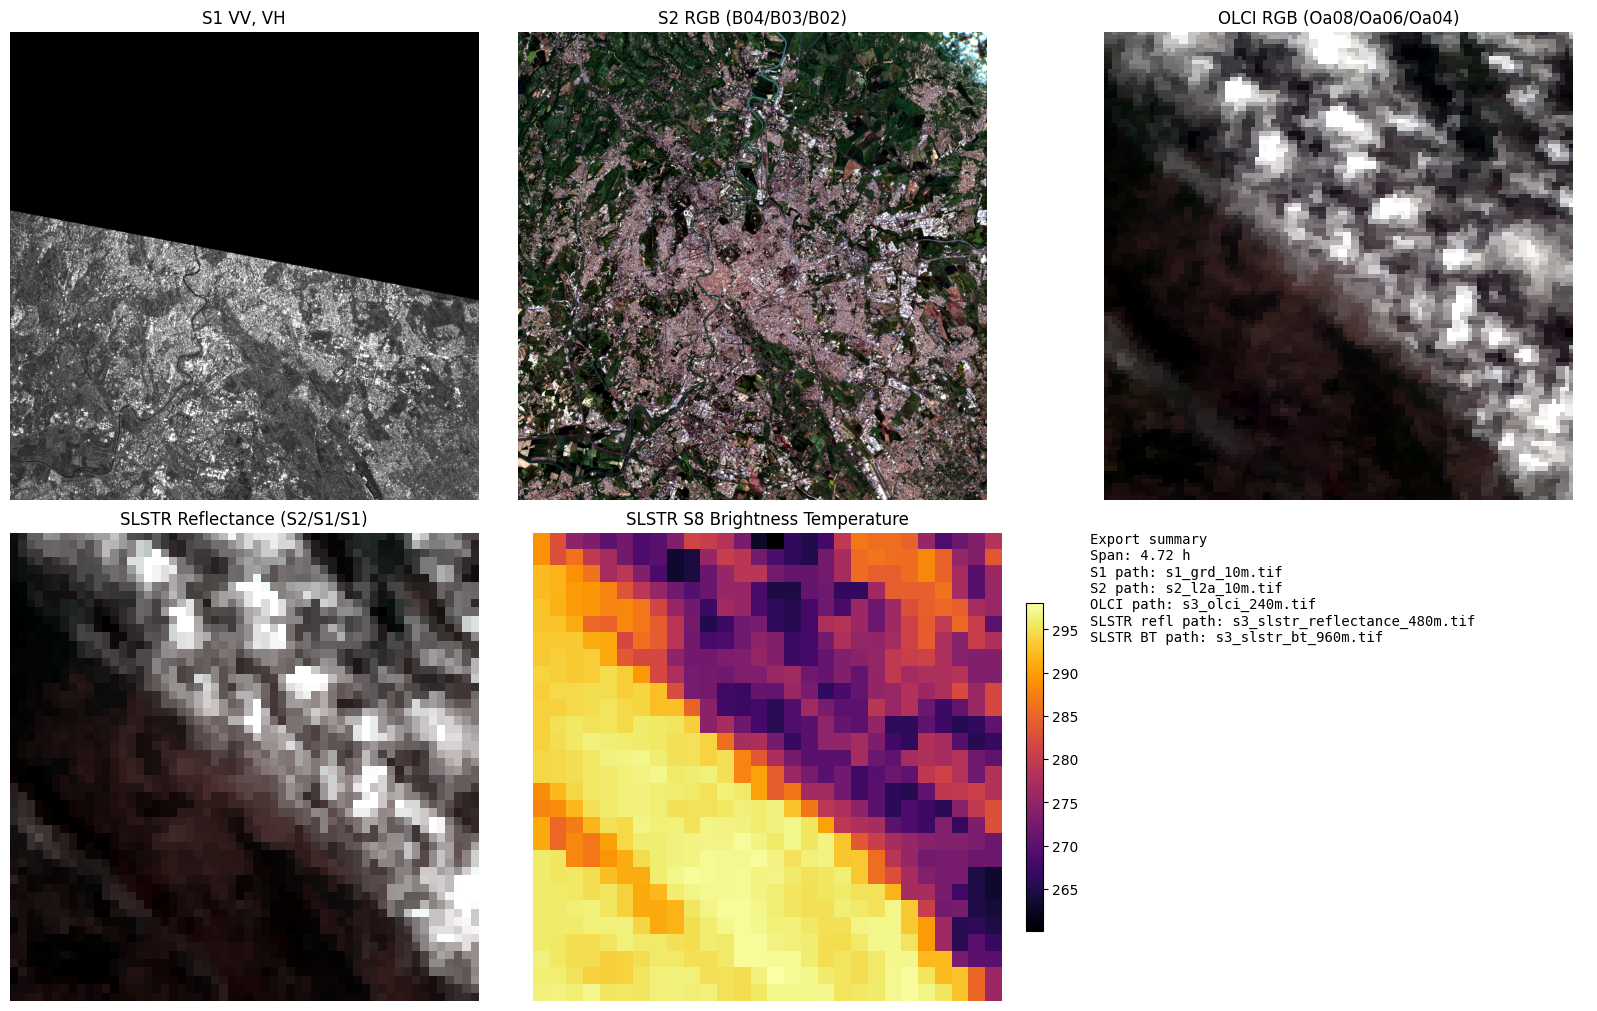

In [12]:
def read_stack(path: Path) -> tuple[np.ndarray, list[str]]:
    with rasterio.open(path) as src:
        return src.read().astype(np.float32), list(src.descriptions)


s1_stack, s1_band_names = read_stack(export_paths["S1GRD"])
s2_stack, s2_band_names = read_stack(export_paths["S2L2A"])
olci_stack, olci_band_names = read_stack(export_paths["S3OLCI"])
slstr_refl_stack, slstr_refl_band_names = read_stack(export_paths["S3SLSTR_REFL"])
slstr_bt_stack, slstr_bt_band_names = read_stack(export_paths["S3SLSTR_BT"])

fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

axes[0].imshow(stretch_rgb(np.repeat(s1_stack[:1], 3, axis=0)))
axes[0].set_title(f"S1 {', '.join(s1_band_names)}")
axes[0].axis("off")

axes[1].imshow(stretch_rgb(s2_stack[[3, 2, 1], :, :]))
axes[1].set_title("S2 RGB (B04/B03/B02)")
axes[1].axis("off")

axes[2].imshow(stretch_rgb(olci_stack[[7, 5, 3], :, :]))
axes[2].set_title("OLCI RGB (Oa08/Oa06/Oa04)")
axes[2].axis("off")

axes[3].imshow(stretch_rgb(slstr_refl_stack[[1, 0, 0], :, :]))
axes[3].set_title("SLSTR Reflectance (S2/S1/S1)")
axes[3].axis("off")

bt_image = axes[4].imshow(slstr_bt_stack[1], cmap="inferno")
axes[4].set_title("SLSTR S8 Brightness Temperature")
axes[4].axis("off")
fig.colorbar(bt_image, ax=axes[4], shrink=0.7)

axes[5].axis("off")
summary_lines = [
    "Export summary",
    f"Span: {selected_metrics['span_hours']:.2f} h",
    f"S1 path: {export_paths['S1GRD'].name}",
    f"S2 path: {export_paths['S2L2A'].name}",
    f"OLCI path: {export_paths['S3OLCI'].name}",
    f"SLSTR refl path: {export_paths['S3SLSTR_REFL'].name}",
    f"SLSTR BT path: {export_paths['S3SLSTR_BT'].name}",
]
axes[5].text(0.0, 1.0, "\n".join(summary_lines), va="top", family="monospace")

plt.show()

## Dict-Style Modality Example For THOR Or Terratorch

A practical downstream interface is a dict-style model input such as:

```python
model({
    "S2L2A": s2_input,
    "S1GRD": s1_input,
})
```

This section shows how the exported GeoTIFFs map into that structure. The notebook keeps the modalities separate first and only turns them into tensors at the end. That makes the preprocessing path compatible with terratorch-style dataset code even before THOR itself accepts dict inputs.

In [13]:
modality_arrays = {
    "S1GRD": read_stack(export_paths["S1GRD"])[0],
    "S2L2A": read_stack(export_paths["S2L2A"])[0],
    "S3OLCI": read_stack(export_paths["S3OLCI"])[0],
    "S3SLSTR_REFL": read_stack(export_paths["S3SLSTR_REFL"])[0],
    "S3SLSTR_BT": read_stack(export_paths["S3SLSTR_BT"])[0],
}
if export_s3_combined_240m:
    modality_arrays["S3COMBINED"] = read_stack(export_paths["S3COMBINED"])[0]

shape_df = pd.DataFrame(
    {
        "modality": list(modality_arrays),
        "shape_c_h_w": [tuple(array.shape) for array in modality_arrays.values()],
    }
)
display(shape_df)

try:
    import torch
except ImportError:
    print("Install torch if you want to materialise a tensor dictionary directly from the exported GeoTIFFs.")
else:
    tensor_inputs = {
        key: torch.from_numpy(value).unsqueeze(0)
        for key, value in modality_arrays.items()
    }
    print({key: tuple(value.shape) for key, value in tensor_inputs.items()})
    example_lines = [
        "Example: model({",
        "    'S2L2A': tensor_inputs['S2L2A'],",
        "    'S1GRD': tensor_inputs['S1GRD'],",
        "    'S3OLCI': tensor_inputs['S3OLCI'],",
        "    'S3SLSTR_REFL': tensor_inputs['S3SLSTR_REFL'],",
        "    'S3SLSTR_BT': tensor_inputs['S3SLSTR_BT'],",
        "})",
    ]
    print("\n".join(example_lines))

,modality,shape_c_h_w
0,S1GRD,"(2, 2688, 2688)"
1,S2L2A,"(12, 2688, 2688)"
2,S3OLCI,"(21, 112, 112)"
3,S3SLSTR_REFL,"(6, 56, 56)"
4,S3SLSTR_BT,"(3, 28, 28)"


Install torch if you want to materialise a tensor dictionary directly from the exported GeoTIFFs.


## Verification Gates

This final section encodes the invariants we expect from a successful export:
- all exported rasters share the same CRS,
- all exported rasters share the same aligned origin,
- band counts match the requested modality definitions,
- equal-resolution outputs share equal width and height,
- and the optional fused Sentinel-3 file matches the OLCI 240 m grid exactly.

If any assertion fails, treat it as a notebook bug or an environment problem until proven otherwise.

In [14]:
verification_rows = []
for modality, path in export_paths.items():
    with rasterio.open(path) as src:
        verification_rows.append(
            {
                "modality": modality,
                "path": str(path),
                "crs": str(src.crs),
                "origin_x": src.transform.c,
                "origin_y": src.transform.f,
                "resolution_x": src.transform.a,
                "resolution_y": -src.transform.e,
                "width": src.width,
                "height": src.height,
                "band_count": src.count,
            }
        )
verification_df = pd.DataFrame(verification_rows).sort_values(["resolution_x", "modality"]).reset_index(drop=True)
display(verification_df)

assert verification_df["crs"].nunique() == 1, "Exported rasters do not share the same CRS"
assert verification_df["origin_x"].nunique() == 1, "Exported rasters do not share one aligned X origin"
assert verification_df["origin_y"].nunique() == 1, "Exported rasters do not share one aligned Y origin"

verification_indexed = verification_df.set_index("modality")
assert verification_indexed.loc["S2L2A", "band_count"] == len(s2_band_order), "S2 band count mismatch"
assert verification_indexed.loc["S3OLCI", "band_count"] == len(OLCI_BAND_NAMES), "OLCI band count mismatch"
assert verification_indexed.loc["S3SLSTR_REFL", "band_count"] == len(SLSTR_REFLECTANCE_BANDS), "SLSTR reflectance band count mismatch"
assert verification_indexed.loc["S3SLSTR_BT", "band_count"] == len(SLSTR_BT_BANDS), "SLSTR BT band count mismatch"
assert verification_indexed.loc["S1GRD", "band_count"] >= 1, "S1 export is empty"

if int(s1_target_resolution_m) == int(s2_target_resolution_m):
    assert verification_indexed.loc["S1GRD", "width"] == verification_indexed.loc["S2L2A", "width"], "S1 and S2 widths differ at the same target GSD"
    assert verification_indexed.loc["S1GRD", "height"] == verification_indexed.loc["S2L2A", "height"], "S1 and S2 heights differ at the same target GSD"

if export_s3_combined_240m:
    for field in ["width", "height", "origin_x", "origin_y", "resolution_x", "resolution_y"]:
        assert (
            verification_indexed.loc["S3COMBINED", field] == verification_indexed.loc["S3OLCI", field]
        ), f"S3 combined grid does not match OLCI grid for {field}"

print("Verification passed: modality exports share one CRS, one aligned origin, and the requested band counts.")

,modality,path,crs,origin_x,origin_y,resolution_x,resolution_y,width,height,band_count
0,S1GRD,/home/theodor/Projects/phidown/notebooks/out/9_s1_s2_s3_thor_workflow/s1_grd_10m.tif,EPSG:32633,279360.0,4656000.0,10.0,10.0,2688,2688,2
1,S2L2A,/home/theodor/Projects/phidown/notebooks/out/9_s1_s2_s3_thor_workflow/s2_l2a_10m.tif,EPSG:32633,279360.0,4656000.0,10.0,10.0,2688,2688,12
2,S3OLCI,/home/theodor/Projects/phidown/notebooks/out/9_s1_s2_s3_thor_workflow/s3_olci_240m.tif,EPSG:32633,279360.0,4656000.0,240.0,240.0,112,112,21
3,S3SLSTR_REFL,/home/theodor/Projects/phidown/notebooks/out/9_s1_s2_s3_thor_workflow/s3_slstr_reflectance_480m.tif,EPSG:32633,279360.0,4656000.0,480.0,480.0,56,56,6
4,S3SLSTR_BT,/home/theodor/Projects/phidown/notebooks/out/9_s1_s2_s3_thor_workflow/s3_slstr_bt_960m.tif,EPSG:32633,279360.0,4656000.0,960.0,960.0,28,28,3


Verification passed: modality exports share one CRS, one aligned origin, and the requested band counts.
